Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4154
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3261
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3099
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3006
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2948
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


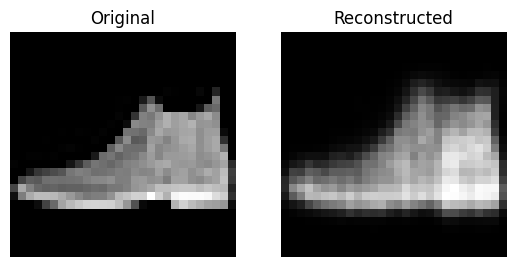

In [1]:
# 1 

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load and preprocess data
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

# Autoencoder
inp = Input(shape=(784,))
encoded = Dense(32, activation='relu')(inp)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(inp, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(x_train, x_train, epochs=5, batch_size=256, verbose=1)

# Reconstruct one image
reconstructed = autoencoder.predict(x_test[:1])

# Display original and reconstructed image
plt.subplot(1, 2, 1)
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed[0].reshape(28, 28), cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


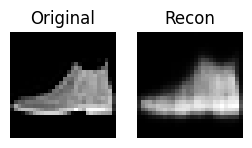

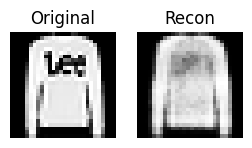

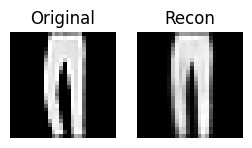

In [2]:
# 2 

inp = Input(shape=(784,))
encoded = Dense(32, activation='relu')(inp)
decoded = Dense(784, activation='sigmoid')(encoded)

model = Model(inp, decoded)
model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(x_train, x_train, epochs=5, batch_size=256, verbose=0)

# Reconstruct 3 images
pred = model.predict(x_test[:3])

# Show Original vs Reconstructed
for i in range(3):
    plt.figure(figsize=(3,2))

    plt.subplot(1,2,1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(pred[i].reshape(28,28), cmap='gray')
    plt.title("Recon")
    plt.axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


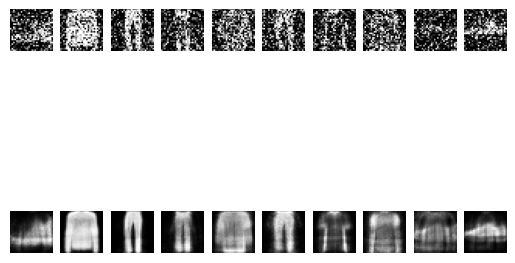

In [3]:
# 3 
import numpy as np
import matplotlib.pyplot as plt

# Add noise to 10 test images
noisy = x_test[:10] + 0.5 * np.random.randn(10, 784)
noisy = np.clip(noisy, 0, 1)

# Denoise using trained autoencoder
denoised = model.predict(noisy)

# Show noisy and denoised images
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(denoised[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


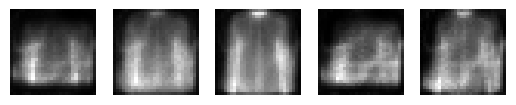

In [7]:
# 4 
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

# Data
(x_train,_),_=tf.keras.datasets.fashion_mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_train=x_train.reshape(-1,784)

latent_dim=2

# Encoder
inp=layers.Input(shape=(784,))
h=layers.Dense(64,activation='relu')(inp)
z_mean=layers.Dense(latent_dim)(h)
z_log_var=layers.Dense(latent_dim)(h)

def sample(args):
    m,v=args
    eps=tf.random.normal((tf.shape(m)[0],latent_dim))
    return m+tf.exp(0.5*v)*eps

z=layers.Lambda(sample)([z_mean,z_log_var])

# Decoder
zin=layers.Input(shape=(latent_dim,))
out=layers.Dense(784,activation='sigmoid')(layers.Dense(64,activation='relu')(zin))
decoder=Model(zin,out)

# VAE
vae=Model(inp,decoder(z))
vae.compile(optimizer='adam',loss='binary_crossentropy')
vae.fit(x_train,x_train,epochs=5,batch_size=128,verbose=0)

# Generate 5 images
z=np.random.normal(size=(5,latent_dim))
imgs=decoder.predict(z)

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(imgs[i].reshape(28,28),cmap='gray')
    plt.axis('off')
plt.show()

5 
KL-divergence (Kullback-Leibler divergence) loss in a VAE measures how different the encoder's learned latent distribution is from a standard normal distribution (mean = 0, variance = 1). It acts as a regularization term that encourages the latent space to be smooth and well-organized.

Without KL-divergence loss, the encoder could place data points anywhere in the latent space, making it difficult to generate meaningful new samples. By forcing the latent representations to stay close to a normal distribution, the decoder can generate realistic outputs even from randomly sampled latent vectors.

In simple terms, the reconstruction loss helps the VAE recreate the input accurately, while the KL-divergence loss ensures that the latent space remains structured and suitable for generating new data. Both losses work together to make the VAE effective for data generation.